In [11]:
import pandas as pd #
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from scipy.spatial.distance import mahalanobis
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
#df1 = pd.read_csv("./../../data/dev101_prepared.csv")
#df2 = pd.read_csv("./../../data/dev102_prepared.csv")
df_all = pd.read_csv("/content/drive/MyDrive/Landslide project/Isolation forest/data label 30 seconds frequency.csv")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
#df_all = pd.concat([df1, df2], ignore_index=True)
df_all.describe()

,devID,soil,rain,temp,humi,geo,hour
count,4886.0,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000
mean,101.0,43.201280,0.957657,29.737210,77.011197,10.891998,11.603971
std,0.0,10.612681,4.055136,2.728695,6.179554,4.259171,6.991744
min,101.0,27.349999,0.000000,25.392539,60.727067,0.935658,0.000000
25%,101.0,27.900000,0.000000,27.359680,72.030584,7.661707,5.000000
50%,101.0,49.000000,0.000000,28.951864,80.122716,10.244194,12.000000
75%,101.0,50.900002,0.000000,32.588072,81.522494,13.793385,18.000000
max,101.0,55.799999,40.932100,35.655504,85.420616,32.019947,23.000000


In [16]:
# Select features

#feature_cols = [
#    'soil', 'rain', 'temp', 'humi', 'geo',
#    'rain_1h_sum', 'rain_3h_sum', 'rain_6h_sum', 'rain_12h_sum', 'rain_1d_sum', 'rain_7d_sum',
#    'soil_1h_mean', 'soil_3h_mean', 'soil_6h_mean', 'soil_12h_mean', 'soil_1d_mean',
#    'geo_1h_mean', 'geo_3h_mean', 'geo_6h_mean', 'geo_12h_mean', 'geo_1d_mean',
#    'soil_diff', 'geo_diff', 'soil_1h_std', 'geo_1h_std'
#]

feature_cols = [
    'soil', 'rain', 'temp', 'humi', 'geo',
]

#feature_cols = [
#    'soil', 'rain', 'temp', 'humi', 'geo',
#    'rain_1h_sum', 'rain_3h_sum', 'rain_6h_sum', 'rain_12h_sum',
#    'soil_1h_mean', 'soil_3h_mean', 'soil_6h_mean', 'soil_12h_mean',
#    'geo_1h_mean', 'geo_3h_mean', 'geo_6h_mean', 'geo_12h_mean',
#]

In [17]:
missing = [col for col in feature_cols if col not in df_all.columns]
if missing:
    raise ValueError(f"ขาดคอลัมน์ในข้อมูลทั้งหมด: {missing}")

In [18]:
df_all

,timestamp,devID,soil,rain,temp,humi,geo,hour,label
0,5/2/2025 12:00,101,28.766666,0.0,35.233590,61.564409,14.308251,12,NaN
1,5/2/2025 12:00,101,28.799999,0.0,35.331501,62.408737,15.891333,12,NaN
2,5/2/2025 12:01,101,28.799999,0.0,35.379566,61.602236,14.088287,12,NaN
3,5/2/2025 12:01,101,28.766666,0.0,35.430302,63.564610,15.119175,12,NaN
4,5/2/2025 12:02,101,28.766666,0.0,35.508638,64.492868,14.641307,12,NaN
...,...,...,...,...,...,...,...,...,...
4881,5/4/2025 11:55,101,48.366667,0.0,33.772026,69.169754,10.193673,11,NaN
4882,5/4/2025 11:56,101,48.400002,0.0,33.766685,69.380520,14.183249,11,NaN
4883,5/4/2025 11:57,101,48.400002,0.0,33.756004,67.130768,8.703913,11,NaN
4884,5/4/2025 11:57,101,48.350000,0.0,33.789387,68.244675,8.998999,11,NaN


In [20]:
# ==== Split Data & Scaling ====

df_train, df_temp = train_test_split(df_all, test_size=0.2, random_state=42)
df_val, df_test = train_test_split(df_temp, test_size=0.35, random_state=42)

print(f"Train: {len(df_train)}, Validation: {len(df_val)}, Test: {len(df_test)}")

# Extract
X_train = df_train[feature_cols].values
X_val = df_val[feature_cols].values
X_test = df_test[feature_cols].values

df_validate_combined = pd.concat([df_val, df_test], ignore_index=True)
df_validate_combined.to_csv("/content/drive/MyDrive/Landslide project/Isolation forest/validate.csv", index=False)
print(f"validate.csv (rows: {len(df_validate_combined)})")

Train: 3908, Validation: 635, Test: 343
validate.csv (rows: 978)


In [21]:
# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

#X_train_scaled = X_train
#X_val_scaled = X_val
#X_test_scaled = X_test

In [22]:
# ==== Train Isolation Forest ====
iso_model = IsolationForest(n_estimators=50, contamination=0.03, random_state=42)
iso_model.fit(X_train_scaled)

IsolationForest(contamination=0.03, n_estimators=50, random_state=42)

In [23]:
# Add anomaly scores
df_train['anomaly_score'] = iso_model.decision_function(X_train_scaled)
df_val['anomaly_score'] = iso_model.decision_function(X_val_scaled)
df_test['anomaly_score'] = iso_model.decision_function(X_test_scaled)

In [24]:

# ==== Thresholds & Risk Level Classification ====

crit_thresh = np.percentile(df_train['anomaly_score'], 0.5)
warn_thresh = np.percentile(df_train['anomaly_score'], 5)

#crit_thresh = -0.11
#warn_thresh = 0.00

def classify_risk(score):
    if score < crit_thresh:
        return "Critical"
    elif score < warn_thresh:
        return "Warning"
    else:
        return "Normal"

for df in [df_train, df_val, df_test]:
    df['risk_level'] = df['anomaly_score'].apply(classify_risk)
print("crit_thresh:", crit_thresh)
print("warn_thresh:", warn_thresh)

crit_thresh: -0.048828825451188176
warn_thresh: 0.017532326345269907


## Validate

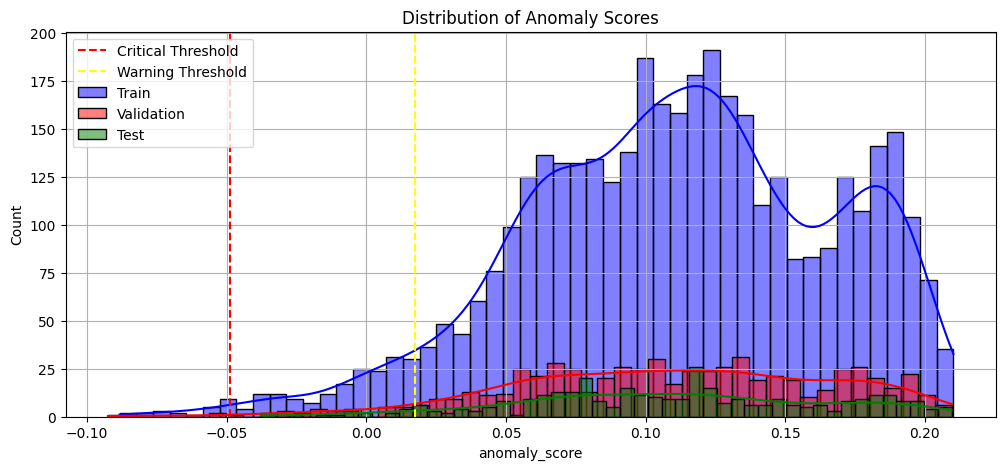

In [25]:
# Distribution of Anomaly Scores

plt.figure(figsize=(12,5))
sns.histplot(df_train['anomaly_score'], bins=50, kde=True, color='blue', label='Train')
sns.histplot(df_val['anomaly_score'], bins=50, kde=True, color='red', label='Validation')
sns.histplot(df_test['anomaly_score'], bins=50, kde=True, color='green', label='Test')
plt.axvline(crit_thresh, color='red', linestyle='--', label='Critical Threshold')
plt.axvline(warn_thresh, color='yellow', linestyle='--', label='Warning Threshold')
plt.title('Distribution of Anomaly Scores')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
print("\n== Risk Proportion ==")
print("Train:", df_train['risk_level'].value_counts(normalize=True))
print("Validation:", df_val['risk_level'].value_counts(normalize=True))
print("Test:", df_test['risk_level'].value_counts(normalize=True))


== Risk Proportion ==
Train: risk_level
Normal      0.949846
Warning     0.045036
Critical    0.005118
Name: proportion, dtype: float64
Validation: risk_level
Normal      0.948031
Warning     0.044094
Critical    0.007874
Name: proportion, dtype: float64
Test: risk_level
Normal     0.953353
Warning    0.046647
Name: proportion, dtype: float64


In [27]:
from joblib import dump
dump(scaler, '/content/drive/MyDrive/Landslide project/Isolation forest/iso_scaler2.joblib')
dump(iso_model, '/content/drive/MyDrive/Landslide project/Isolation forest/iso_model2.joblib')

['/content/drive/MyDrive/Landslide project/Isolation forest/iso_model2.joblib']

In [ ]:
"""

from joblib import load
scaler = load('scaler.joblib')
model = load('iso_model.joblib')

x_new = scaler.transform([[soil, rain, temp, humi, geo]])
score = model.decision_function(x_new)

if score < -0.2:
    risk = "Critical"
elif score < 0.0:
    risk = "Warning"
else:
    risk = "Normal"

    """